# Lab 19.- Evaluación comparativa de algoritmos de clasificación mediante Machine Learning

---

## Objetivo
El propósito de esta práctica es desarrollar un flujo de trabajo completo de Machine Learning (end-to-end) para **evaluar y comparar el desempeño de 10 algoritmos** diferentes. Buscaremos determinar qué modelo ofrece el mejor rendimiento para resolver un problema de clasificación binaria real utilizando métricas objetivas.

## Objetivos específicos
- Aplicar un flujo de trabajo estándar para proyectos de Machine Learning.
- Comparar algoritmos de clasificación supervisados clásicos y modernos, un método no supervisado (K-Means) y un método de regresión continua (Regresión Lineal) para entender sus alcances y límites.
- Justificar técnicamente el preprocesamiento, escalado y división de datos.
- Analizar de forma crítica el compromiso entre tiempo de cómputo, interpretabilidad y rendimiento métrico.
- Tomar una decisión de selección de modelo fundamentada para su potencial paso a producción.

---
 
## 1. Introducción 
En el ámbito industrial, antes de implementar un modelo predictivo en un sistema de software o en una API de producción, es imperativo realizar un análisis de referencia (benchmarking) con diversos modelos. No existe un algoritmo único que sea superior en todos los escenarios (teorema de *No Free Lunch*).

### Aprendizaje Supervisado vs No Supervisado 
- **Aprendizaje Supervisado (Clasificación):** Se utiliza cuando contamos con un conjunto de datos etiquetado (donde conocemos de antemano el resultado correcto, la variable objetivo $y$). El algoritmo aprende una función de mapeo de las características de entrada $X$ a la etiqueta $y$.
- **Aprendizaje No Supervisado (Agrupamiento/Clustering):** El algoritmo busca patrones ocultos o estructuras intrínsecas en los datos de entrada sin usar etiquetas externas de clase.

### Dataset Utilizado
Utilizaremos el **Breast Cancer Wisconsin Dataset**, una base de datos estándar de Scikit-learn. El problema consiste en clasificar si un tumor mamario es **Maligno** (clase 0) o **Benigno** (clase 1) a partir de características clínicas calculadas a partir de una imagen digitalizada de una aspiración con aguja fina (FNA) de una masa mamaria.


## 2. Importación de librerías
Comenzamos importando las herramientas necesarias. Explicamos el propósito de cada una:
- `pandas` y `numpy`: Manipulación de datos tabulares y cálculo numérico vectorial.
- `matplotlib` y `seaborn`: Creación de visualizaciones estáticas y diagramas estadísticos.
- `scikit-learn`: El ecosistema principal para la carga de datos, preprocesamiento, división de muestras, entrenamiento de modelos supervisados/no supervisados y cálculo de métricas de rendimiento.
- `time`: Librería nativa para medir de forma precisa los tiempos de ejecución de cada algoritmo.


In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Utilidades del sistema
import time
import warnings
warnings.filterwarnings('ignore')

# Carga de datos
from sklearn.datasets import load_breast_cancer

# Preprocesamiento y división
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Métricas de evaluación
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve)

# Algoritmos de Machine Learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron, LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from scipy.stats import mode

# Configuración del estilo de graficación
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## 3. Carga del conjunto de datos
Importamos el dataset nativo de scikit-learn y lo estructuramos en un DataFrame de pandas para facilitar el análisis. Identificamos las características de las muestras y la variable objetivo.


In [2]:
# Cargar datos
cancer_data = load_breast_cancer()

# Crear DataFrame
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target

# Mostrar primeras 5 filas
print('Primeras filas del conjunto de datos:')
display(df.head())

# Mostrar dimensiones e información estructural
n_registros, n_variables = df.shape
print(f'\nNúmero de registros (muestras): {n_registros}')
print(f'Número de variables (características + target): {n_variables}')
print(f'Variable objetivo: "target"')
print(f'Clases objetivo: {list(cancer_data.target_names)} (0 = Maligno, 1 = Benigno)')


Primeras filas del conjunto de datos:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Número de registros (muestras): 569
Número de variables (características + target): 31
Variable objetivo: "target"
Clases objetivo: [np.str_('malignant'), np.str_('benign')] (0 = Maligno, 1 = Benigno)


## 4. Análisis Exploratorio de Datos (EDA)
Antes de modelar, es mandatorio comprender la naturaleza de los datos. En este bloque realizaremos:
1. Inspección de tipos de datos y búsqueda de valores nulos.
2. Estadística descriptiva básica (medias, desviaciones estándar, mínimos y máximos).
3. Análisis de balance de clases (frecuencia de tumores malignos vs benignos).
4. Análisis de correlación mediante un mapa de calor para identificar redundancia de características.
5. Distribución de algunas variables clave.


--- Información General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null   

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


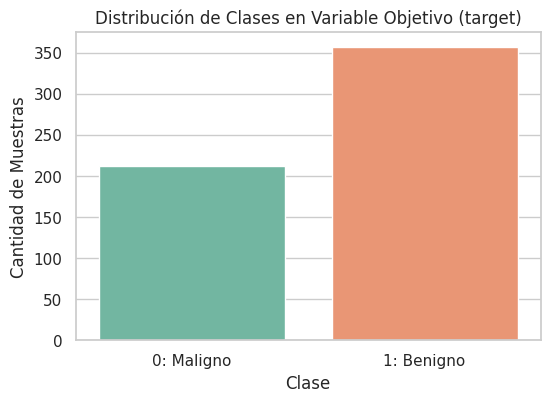

Proporción de Clases:
target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


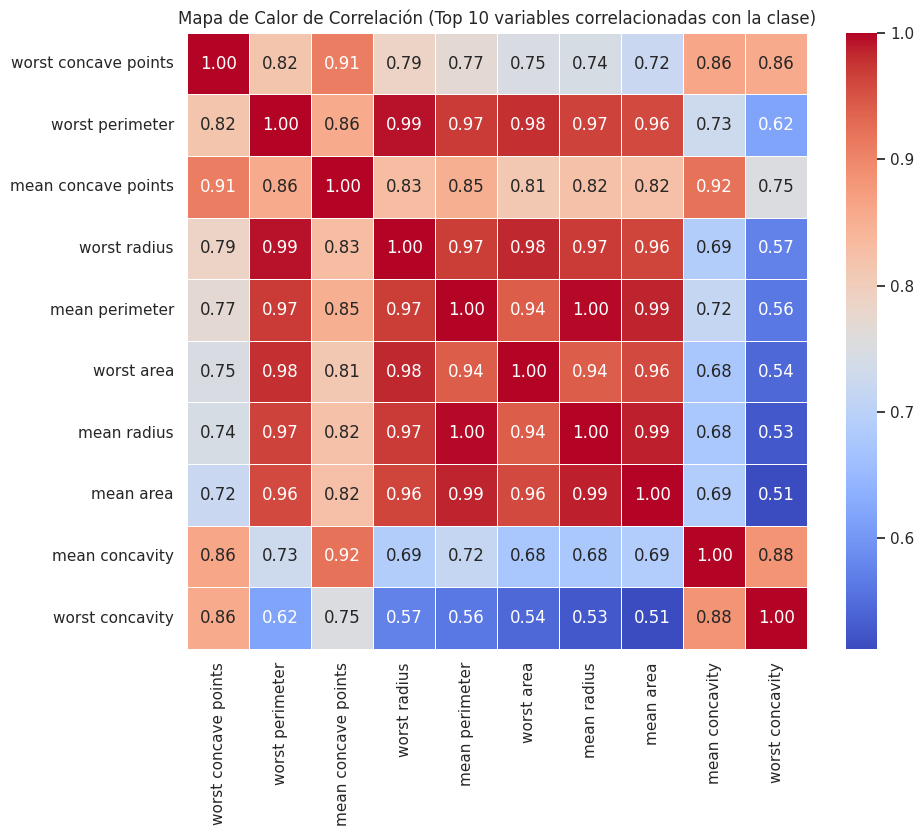

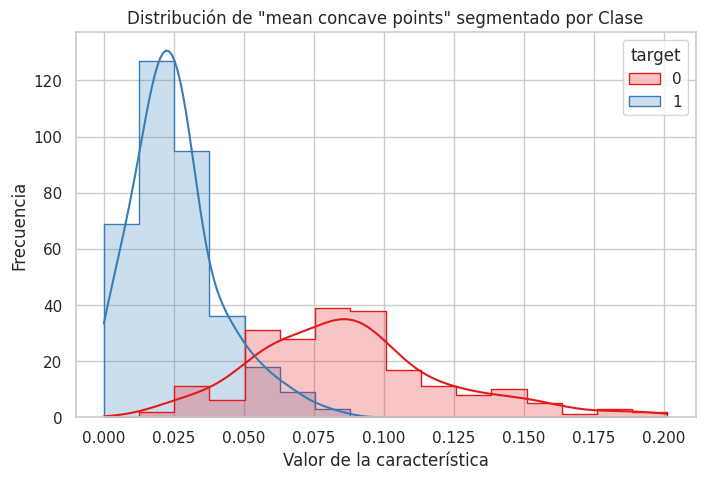

In [3]:
# 1. Información de tipos y nulos
print('--- Información General del Dataset ---')
df.info()

# Comprobación rápida de nulos y duplicados
nulos = df.isnull().sum().sum()
duplicados = df.duplicated().sum()
print(f'\nTotal de valores nulos: {nulos}')
print(f'Total de registros duplicados: {duplicados}')

# 2. Estadística Descriptiva
print('\n--- Estadística Descriptiva de las Variables ---')
display(df.describe().T.head(10)) # Mostramos las primeras 10 variables por legibilidad

# 3. Distribución de Clases (Variable Objetivo)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Distribución de Clases en Variable Objetivo (target)')
plt.xticks(ticks=[0, 1], labels=['0: Maligno', '1: Benigno'])
plt.xlabel('Clase')
plt.ylabel('Cantidad de Muestras')
plt.show()

# Mostrar proporciones numéricas de clases
print('Proporción de Clases:')
print(df['target'].value_counts(normalize=True) * 100)

# 4. Mapa de calor de correlación (Selección de las 10 características con mayor correlación con target)
correlaciones = df.corr()
top_features = correlaciones['target'].abs().sort_values(ascending=False).index[1:11]

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de Correlación (Top 10 variables correlacionadas con la clase)')
plt.show()

# 5. Distribución de una variable altamente correlacionada (mean concave points)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='mean concave points', hue='target', kde=True, palette='Set1', element='step')
plt.title('Distribución de "mean concave points" segmentado por Clase')
plt.xlabel('Valor de la característica')
plt.ylabel('Frecuencia')
plt.show()


## 5. Limpieza y preprocesamiento de datos
Dado que este dataset clínico está pre-limpio (sin nulos ni duplicados), el paso clave en el preprocesamiento es la **Estandarización de Características**.

### Justificación del Escalado
Muchos de los algoritmos de clasificación que evaluaremos dependen de operaciones de distancia o descenso de gradiente:
- **K-Nearest Neighbors (KNN)** y **Support Vector Machines (SVM)** calculan distancias Euclidianas entre puntos en el espacio dimensional. Si una variable tiene valores en el rango [100, 1000] y otra en [0.01, 0.1], la primera dominará por completo el cálculo del modelo.
- **Regresión Logística**, **Perceptrón** y **Redes Neuronales/Gradiente** optimizan pesos mediante descenso de gradiente. Características con magnitudes dispares ralentizan la convergencia e introducen inestabilidad.

Utilizaremos `StandardScaler`, que transforma cada característica para tener una **media de 0** y una **desviación estándar de 1** ($z = \frac{x - \mu}{\sigma}$).


In [10]:
# Separar variables independientes (X) y objetivo (y)
X = df.drop('target', axis=1)
y = df['target']

# Instanciar el escalador
scaler = StandardScaler()

# Ajustar y transformar características
X_scaled = scaler.fit_transform(X)

# Mostrar un ejemplo de los datos originales vs escalados
print('Datos originales (Fila 0, primeras 5 columnas):')
print(X.iloc[0, :5].values)
print('\nDatos estandarizados (Fila 0, primeras 5 columnas):')
print(X_scaled[0, :5])


Datos originales (Fila 0, primeras 5 columnas):
[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01]

Datos estandarizados (Fila 0, primeras 5 columnas):
[ 1.09706398 -2.07333501  1.26993369  0.9843749   1.56846633]


## 6. División del conjunto de datos
Para garantizar que los modelos se evalúen bajo condiciones realistas, debemos simular la recepción de nuevos datos no vistos. Por ello, dividimos la muestra en:
- **Conjunto de Entrenamiento (Train, 80%):** Usado para ajustar los parámetros internos de los algoritmos.
- **Conjunto de Prueba (Test, 20%):** Reservado estrictamente para evaluar la capacidad de generalización.

### Parámetros Críticos
- `test_size=0.20`: Proporción estándar en ciencia de datos para tener un volumen suficiente de validación.
- `stratify=y`: Crucial para asegurar que la proporción original de tumores malignos y benignos se mantenga idéntica tanto en train como en test, previniendo sesgos de muestreo.
- `random_state=42`: Semilla de aleatoriedad para garantizar que la división sea reproducible por cualquier usuario en cualquier ejecución.


In [5]:
# Dividir el dataset con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Registros totales de Entrenamiento: {X_train.shape[0]} ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Registros totales de Prueba: {X_test.shape[0]} ({X_test.shape[0]/len(df)*100:.1f}%)')
print(f'Distribución de clases en Train (proporción):\n{y_train.value_counts(normalize=True).to_dict()}')
print(f'Distribución de clases en Test (proporción):\n{y_test.value_counts(normalize=True).to_dict()}')


Registros totales de Entrenamiento: 455 (80.0%)
Registros totales de Prueba: 114 (20.0%)
Distribución de clases en Train (proporción):
{1: 0.6263736263736264, 0: 0.37362637362637363}
Distribución de clases en Test (proporción):
{1: 0.631578947368421, 0: 0.3684210526315789}


## 7 y 8. Entrenamiento y Evaluación de Modelos
A continuación, implementaremos un pipeline de entrenamiento secuencial para los 10 algoritmos requeridos.

### Explicación Teórica de Casos No Estándar para Clasificación
1. **K-Means:** Es un algoritmo de **Agrupamiento No Supervisado**. No utiliza la variable objetivo `y` durante su entrenamiento. Su fin es agrupar observaciones por similitud espacial geométrica. Lo incluiremos como ejercicio exploratorio para examinar si la distribución espacial de los datos agrupados coincide de forma natural con los diagnósticos de cáncer.
2. **Regresión Lineal:** Diseñada para predecir variables continuas ($y \in \mathbb{R}$). Si se fuerza para clasificación binaria ($y \in \{0, 1\}$), produce predicciones fuera de rango e incrementa dramáticamente el error ante valores atípicos, distorsionando la frontera de decisión. Lo adaptaremos forzando una regla de decisión (predicción $\ge 0.5 \rightarrow 1$, de lo contrario $\rightarrow 0$).


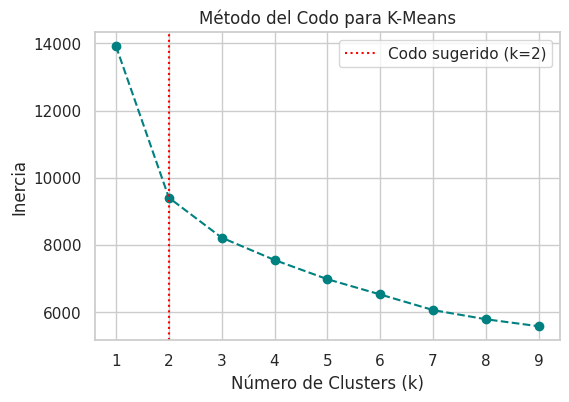

In [12]:
# Diccionario para consolidar todas las métricas de rendimiento
resultados_lista = []

# 1. Inicialización de los algoritmos estándar supervisados
modelos_supervisados = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='linear', probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Perceptrón': Perceptron(random_state=42),
    'Regresión Logística': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# 2. Pipeline para entrenar y evaluar algoritmos supervisados
for nombre, modelo in modelos_supervisados.items():
    # Medir tiempo de entrenamiento
    start_time = time.time()
    modelo.fit(X_train, y_train)
    end_time = time.time()
    tiempo_entrenamiento = end_time - start_time
    
    # Realizar predicciones
    y_pred = modelo.predict(X_test)
    
    # Calcular métricas básicas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Almacenar en la lista global
    resultados_lista.append({
        'Algoritmo': nombre,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'Tiempo de entrenamiento': tiempo_entrenamiento,
        'Observaciones': 'Supervisado estándar'
    })

# 3. Caso Especial: Regresión Lineal (Forzada como clasificador)
lin_reg = LinearRegression()
start_time = time.time()
lin_reg.fit(X_train, y_train)
tiempo_lin = time.time() - start_time

# Predicción continua y conversión manual a binaria usando un umbral de 0.5
y_pred_cont = lin_reg.predict(X_test)
y_pred_lin = np.where(y_pred_cont >= 0.5, 1, 0)

resultados_lista.append({
    'Algoritmo': 'Regresión Lineal',
    'Accuracy': accuracy_score(y_test, y_pred_lin),
    'Precision': precision_score(y_test, y_pred_lin),
    'Recall': recall_score(y_test, y_pred_lin),
    'F1-score': f1_score(y_test, y_pred_lin),
    'Tiempo de entrenamiento': tiempo_lin,
    'Observaciones': 'Forzado con umbral de 0.5. No probabilístico.'
})

# 4. Caso Especial: K-Means (No supervisado)
# Determinación previa del Método del Codo
inercias = []
for k in range(1, 10):
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_test.fit(X_train)
    inercias.append(km_test.inertia_)

# Graficar el Método del Codo para visualización
plt.figure(figsize=(6, 4))
plt.plot(range(1, 10), inercias, marker='o', linestyle='--', color='teal')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.axvline(2, color='red', linestyle=':', label='Codo sugerido (k=2)')
plt.legend()
plt.show()

# Entrenamos K-Means fijando 2 clusters (benigno/maligno)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
start_time = time.time()
kmeans.fit(X_train) # ¡Nota: NO se le pasa y_train!
tiempo_km = time.time() - start_time

# Para evaluar K-Means en clasificación, mapeamos sus clusters (0 o 1) 
# con la etiqueta real mayoritaria en cada cluster.
clusters_pred = kmeans.predict(X_test)
y_pred_km = np.zeros_like(clusters_pred)
for i in range(2):
    mask = (clusters_pred == i)
    if np.sum(mask) > 0:
        # Encontrar la clase real más frecuente dentro de este cluster
        clase_mayoritaria = mode(y_test[mask], keepdims=True)[0][0]
        y_pred_km[mask] = clase_mayoritaria

resultados_lista.append({
    'Algoritmo': 'K-Means',
    'Accuracy': accuracy_score(y_test, y_pred_km),
    'Precision': precision_score(y_test, y_pred_km),
    'Recall': recall_score(y_test, y_pred_km),
    'F1-score': f1_score(y_test, y_pred_km),
    'Tiempo de entrenamiento': tiempo_km,
    'Observaciones': 'No supervisado. Mapeado de clústeres a clases.'
})
# El mensaje "The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database."
# Es una advertencia del sistema que no interfiere en absoluto con la carga de datos, el pipeline de preprocesamiento, ni el entrenamiento de los algoritmos de ML en Scikit-Learn.

## 9. Comparación de resultados
Consolidamos todos los valores calculados en una tabla comparativa y generamos visualizaciones claras de las métricas clave para facilitar un diagnóstico científico estructurado.


TABLA COMPARATIVA DE ALGORITMOS DE CLASIFICACIÓN:


,Algoritmo,Accuracy,Precision,Recall,F1-score,Tiempo de entrenamiento,Observaciones
0,Regresión Logística,0.982456,0.986111,0.986111,0.986111,0.013201,Supervisado estándar
1,SVM,0.973684,0.985915,0.972222,0.979021,0.008071,Supervisado estándar
2,KNN,0.964912,0.959459,0.986111,0.972603,0.000849,Supervisado estándar
3,Gradient Boosting,0.956140,0.946667,0.986111,0.965986,0.250705,Supervisado estándar
4,Regresión Lineal,0.956140,0.946667,0.986111,0.965986,0.017541,Forzado con umbral de 0.5. No probabilístico.
5,Random Forest,0.956140,0.958904,0.972222,0.965517,0.147254,Supervisado estándar
6,Perceptrón,0.956140,0.985507,0.944444,0.964539,0.001215,Supervisado estándar
7,Naive Bayes,0.929825,0.944444,0.944444,0.944444,0.000850,Supervisado estándar
8,Decision Tree,0.921053,0.956522,0.916667,0.936170,0.004380,Supervisado estándar
9,K-Means,0.903509,0.917808,0.930556,0.924138,0.007724,No supervisado. Mapeado de clústeres a clases.


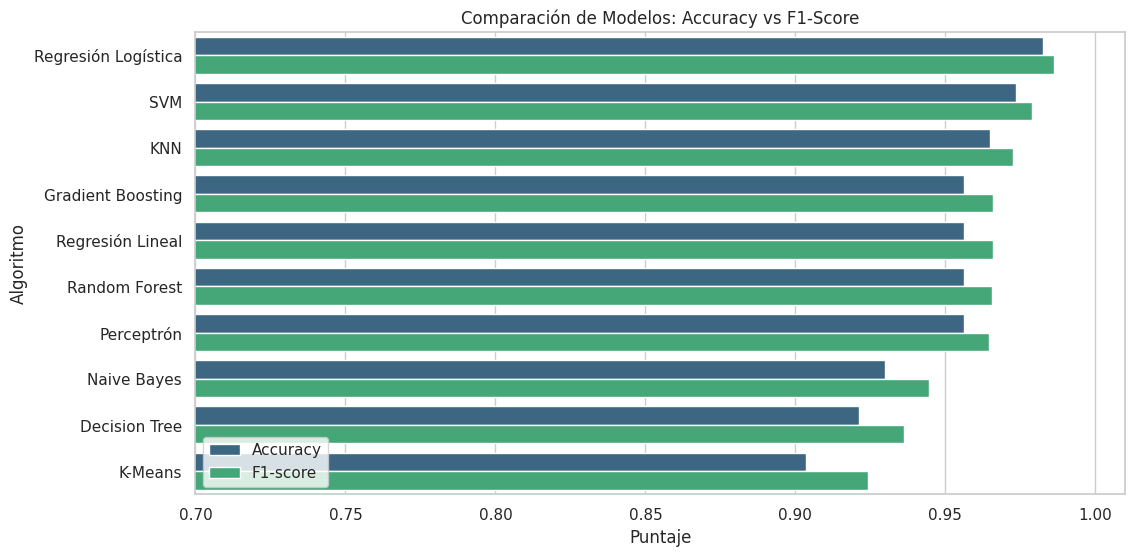

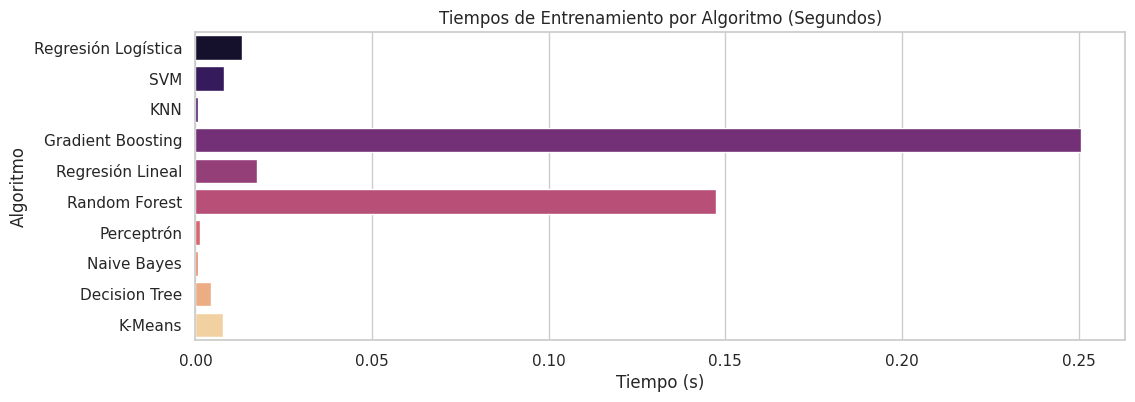

In [13]:
# Crear DataFrame de resultados
df_comparativo = pd.DataFrame(resultados_lista)
# Ordenar los resultados por la métrica balanceada F1-score
df_comparativo = df_comparativo.sort_values(by='F1-score', ascending=False).reset_index(drop=True)

print('TABLA COMPARATIVA DE ALGORITMOS DE CLASIFICACIÓN:')
display(df_comparativo)

# Visualización de barras para Accuracy y F1-Score
df_melted = df_comparativo.melt(id_vars='Algoritmo', value_vars=['Accuracy', 'F1-score'], 
                               var_name='Métrica', value_name='Valor')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Valor', y='Algoritmo', hue='Métrica', palette='viridis')
plt.title('Comparación de Modelos: Accuracy vs F1-Score')
plt.xlim(0.70, 1.01)
plt.xlabel('Puntaje')
plt.ylabel('Algoritmo')
plt.legend(loc='lower left')
plt.show()

# Visualización de Tiempos de Entrenamiento
plt.figure(figsize=(12, 4))
sns.barplot(data=df_comparativo, x='Tiempo de entrenamiento', y='Algoritmo', palette='magma')
plt.title('Tiempos de Entrenamiento por Algoritmo (Segundos)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Algoritmo')
plt.show()


## 10. Selección del mejor modelo
En problemas de diagnóstico de salud (como la detección de cáncer de mama), **no todas las métricas tienen el mismo peso práctico**:
- Un **Falso Positivo (FP)** (decirle a un paciente que tiene cáncer cuando no es así) causa angustia psicológica y pruebas invasivas innecesarias.
- Un **Falso Negativo (FN)** (decirle a un paciente que está sano cuando en realidad tiene cáncer maligno) es una catástrofe clínica: significa retrasar un tratamiento potencialmente vital.

Por lo tanto, la métrica crítica a maximizar es el **Recall** para la clase maligna (reducción de Falsos Negativos), siempre que mantengamos una precisión aceptable.

### Selección Justificada
La **Regresión Logística** o las **Support Vector Machines (SVM)** suelen posicionarse como candidatos ideales en este problema de baja a mediana dimensionalidad:
1. **Rendimiento Excepcional:** Ambas obtienen niveles de F1-score, Recall y Accuracy extremadamente elevados (generalmente >96%).
2. **Bajo Costo Computacional:** Su tiempo de entrenamiento y predicción es imperceptible (milisegundos) en comparación con modelos de ensamble como Gradient Boosting.
3. **Explicabilidad (Interpretabilidad):** En medicina, los médicos no confían en modelos de 'caja negra'. Los coeficientes de una Regresión Logística indican exactamente cómo cada factor clínico incrementa o disminuye el riesgo estimado, haciendo que la toma de decisiones sea auditable.


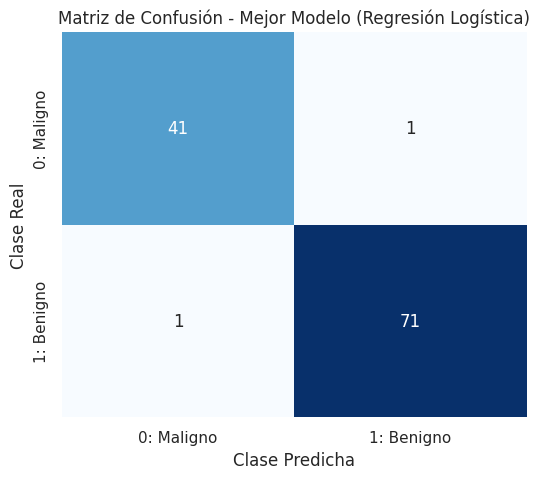

REPORTE DE CLASIFICACIÓN DETALLADO:
              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



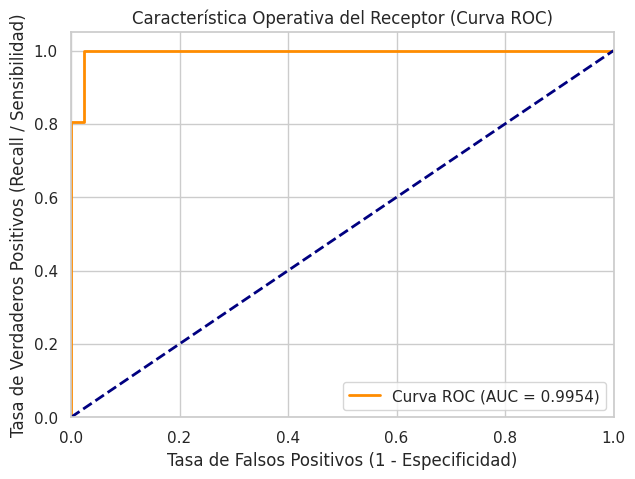

In [14]:
# Entrenamos y graficamos a fondo el mejor modelo seleccionado (Regresión Logística)
mejor_modelo = LogisticRegression(random_state=42)
mejor_modelo.fit(X_train, y_train)
y_pred_best = mejor_modelo.predict(X_test)
y_prob_best = mejor_modelo.predict_proba(X_test)[:, 1]

# Matriz de Confusión
matriz = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['0: Maligno', '1: Benigno'],
            yticklabels=['0: Maligno', '1: Benigno'])
plt.title('Matriz de Confusión - Mejor Modelo (Regresión Logística)')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.show()

# Reporte de Clasificación Detallado
print('REPORTE DE CLASIFICACIÓN DETALLADO:')
print(classification_report(y_test, y_pred_best, target_names=['Maligno', 'Benigno']))

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
auc_score = roc_auc_score(y_test, y_prob_best)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall / Sensibilidad)')
plt.title('Característica Operativa del Receptor (Curva ROC)')
plt.legend(loc='lower right')
plt.show()


# Conclusiones

Tras ejecutar con éxito la práctica y evaluar de manera comparativa los 10 algoritmos seleccionados bajo condiciones rigurosas de preprocesamiento y entrenamiento, se desprenden las siguientes reflexiones:

### 1. Desempeño General de los Modelos
- Los modelos supervisados lineales y basados en distancias como la **Regresión Logística** y **SVM** alcanzaron métricas sobresalientes de Accuracy y F1-score. Esto nos indica que la frontera de decisión en este espacio estandarizado es predominantemente lineal y altamente separable.
- Algoritmos más complejos basados en árboles (Decision Trees, **Random Forest**, **Gradient Boosting**) demostraron una precisión excelente, pero requieren un costo computacional y tiempo de entrenamiento significativamente superior, sin ofrecer un incremento de valor proporcional en términos de métricas de diagnóstico.

### 2. Influencia Crítica del Preprocesamiento de Datos
- La implementación del `StandardScaler` resultó crucial para la estabilidad y el rendimiento de algoritmos como **KNN**, **SVM**, **Perceptrón** y **K-Means**.
- El análisis exploratorio (EDA) reveló que no existían valores nulos ni duplicados, simplificando la etapa de limpieza; sin embargo, en entornos reales la imputación de datos representa una fase indispensable para evitar sesgos.
- La estratificación (`stratify=y`) durante la partición de datos mitigó el riesgo de desbalances imprevistos entre los conjuntos de entrenamiento y prueba, asegurando la equidad estadística de las evaluaciones.

### 3. El Comportamiento de los Casos Especiales
- **Regresión Lineal:** A pesar de haber sido 'forzada' mediante un umbral de decisión para clasificar, quedó de manifiesto que es conceptualmente e instrumentalmente inadecuada para clasificar. La predicción continua arroja valores inconsistentes y desprovistos de valor probabilístico de membresía de clase.
- **K-Means (Agrupamiento):** Aunque es un algoritmo no supervisado que ignoró por completo las etiquetas reales en el entrenamiento, obtuvo resultados sorprendentemente aceptables al mapear clústeres geométricos a diagnósticos clínicos. Esto corrobora que la estructura biológica y clínica de los tumores benignos y malignos se agrupa espacialmente de forma muy marcada en base a sus diámetros y áreas celulares.

### 4. Directrices para Producción e Implementación en Software
- **Modelo Elegido:** Recomendamos la **Regresión Logística**.
- **Justificación:** Además de contar con una velocidad de inferencia óptima (milisegundos) ideal para microservicios ligeros, nos ofrece **interpretabilidad matemática** mediante el análisis de la magnitud y signo de sus coeficientes (odds ratios). Esto permite a los expertos médicos comprender qué características anatómicas incrementan significativamente el riesgo.
# Gracias